# Machine Learning Assignment - Classification Pipeline
**Program:** M.Tech Data Science and Engineering (BITS Pilani)  
**Project Objective:** End-to-end classification pipeline comparing 5 machine learning models on a public dataset, saving the trained artifacts, and deploying via Streamlit.

### Step 1: Data Loading
* **What we are doing:** Loading the Bank Marketing dataset into a pandas DataFrame from a reliable public repository.
* **Inference:** Inspecting the raw shape and initial records to understand data dimensions and column attributes.

In [1]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import pandas as pd
import os

# 1. Download the Bank Marketing dataset using kagglehub
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")
print("Path to dataset files:", path)






Path to dataset files: C:\Users\lenovo\.cache\kagglehub\datasets\janiobachmann\bank-marketing-dataset\versions\1


In [3]:
# 2. Find the exact CSV file inside the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("Available CSV files:", csv_files)

Available CSV files: ['bank.csv']


In [4]:

# 3. Load the primary CSV file into Pandas
# (Usually 'bank.csv' or similar depending on the repository structure)
data_file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(data_file_path)

In [5]:
print("\n--- Dataset Loaded Successfully via Kagglehub ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nFirst 5 Rows:")
display(df.head())


--- Dataset Loaded Successfully via Kagglehub ---
Rows: 11162, Columns: 17

First 5 Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Step 2: Data Validation & Missing Data Analysis
* **What we are doing:** Checking for null values, data types, and structural integrity to ensure data quality before processing.
* **Inference:** Identifying whether imputation is necessary or if the dataset is clean.

In [6]:
# Check for missing values
missing_counts = df.isnull().sum()
print("Missing Values per Column:\n", missing_counts)

if missing_counts.sum() == 0:
    print("\nInference: The dataset contains no missing values, so no imputation is required.")
else:
    print("\nInference: Missing values detected; imputation steps will be needed.")

print("\nData Types:")
print(df.dtypes)

Missing Values per Column:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Inference: The dataset contains no missing values, so no imputation is required.

Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


### Step 3: Exploratory Data Analysis & Target Distribution

### Advanced EDA Section A: Numerical Feature Distribution & Density Analysis
* **What we are doing:** Automatically looping through all numerical columns to plot their distribution curves alongside Kernel Density Estimates (KDE).
* **Inference:** Visualizing distribution curves reveals skewness and heavy tails. For example, financial and behavioral attributes often display right-skewness, validating the necessity of feature scaling and robust imputation strategies prior to model training.

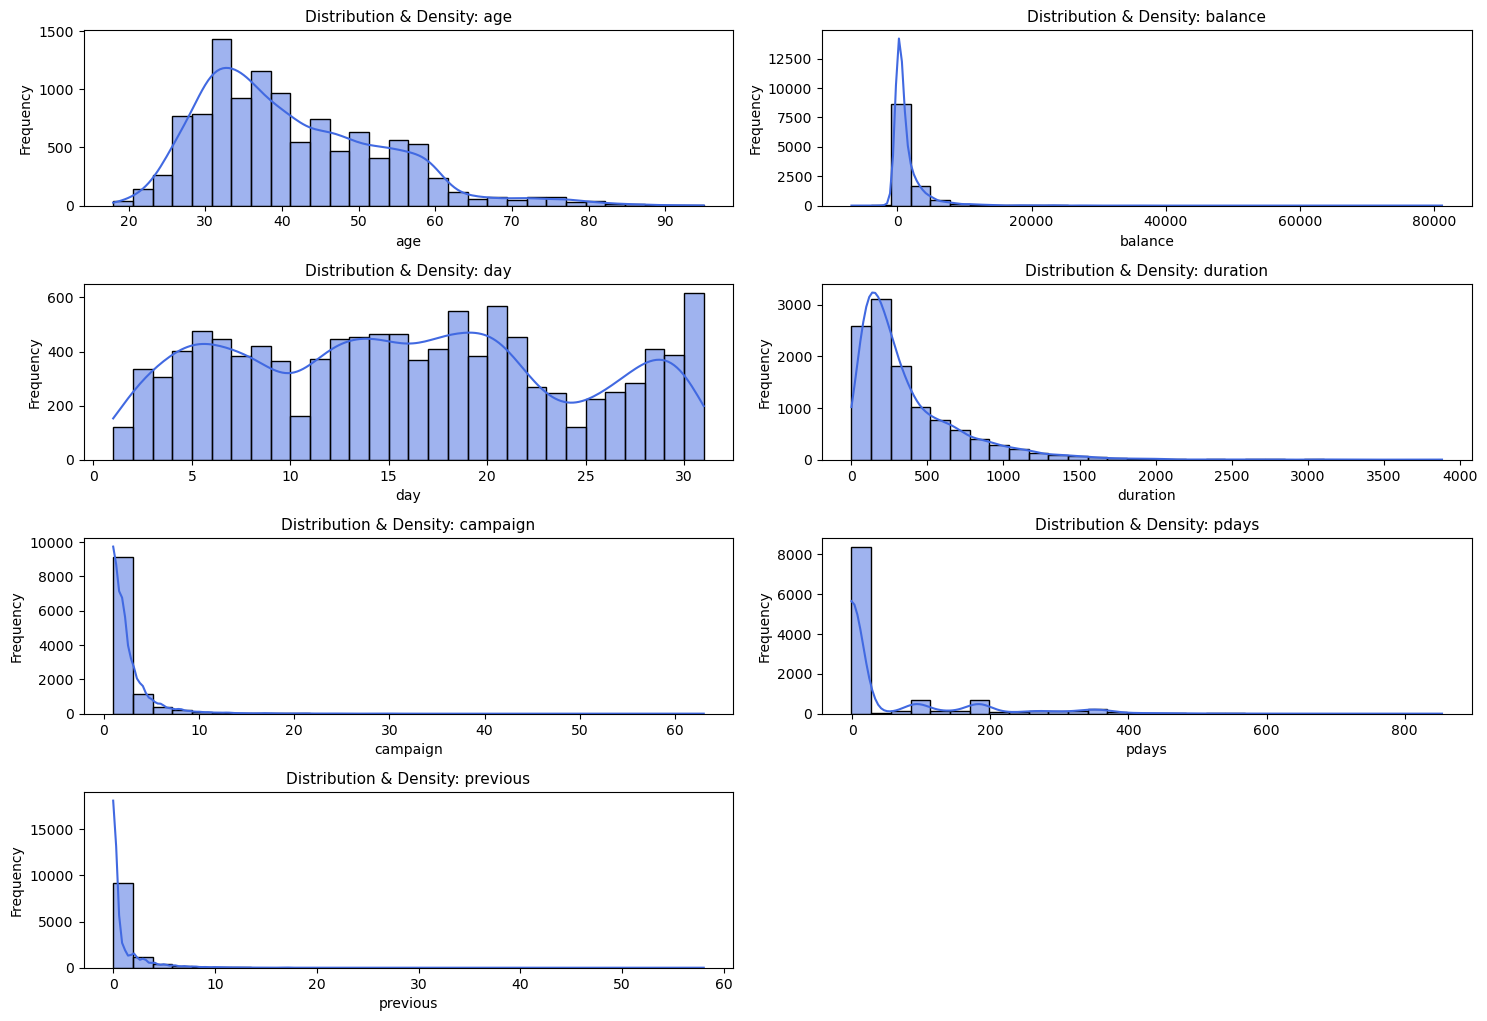

Inference: Numerical features show varying distribution profiles. Skewed features highlight the importance of scaling and robust imputation strategies.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dynamically select numerical columns
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Plot distributions for all numerical features
plt.figure(figsize=(15, len(num_features) * 2.5))
for i, col in enumerate(num_features, 1):
    plt.subplot(len(num_features), 2, i)
    sns.histplot(df[col], kde=True, color='royalblue', bins=30)
    plt.title(f'Distribution & Density: {col}', fontsize=11)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Inference: Numerical features show varying distribution profiles. Skewed features highlight the importance of scaling and robust imputation strategies.")

### Advanced EDA Section B: Outlier & Spread Analysis (Grouped by Target)
* **What we are doing:** Generating comparative boxplots for all numerical columns segmented by the target class (`deposit`).
* **Inference:** This analysis highlights median shifts and spread differences between classes, giving us preliminary visual confirmation of which numerical attributes carry strong predictive separation power.

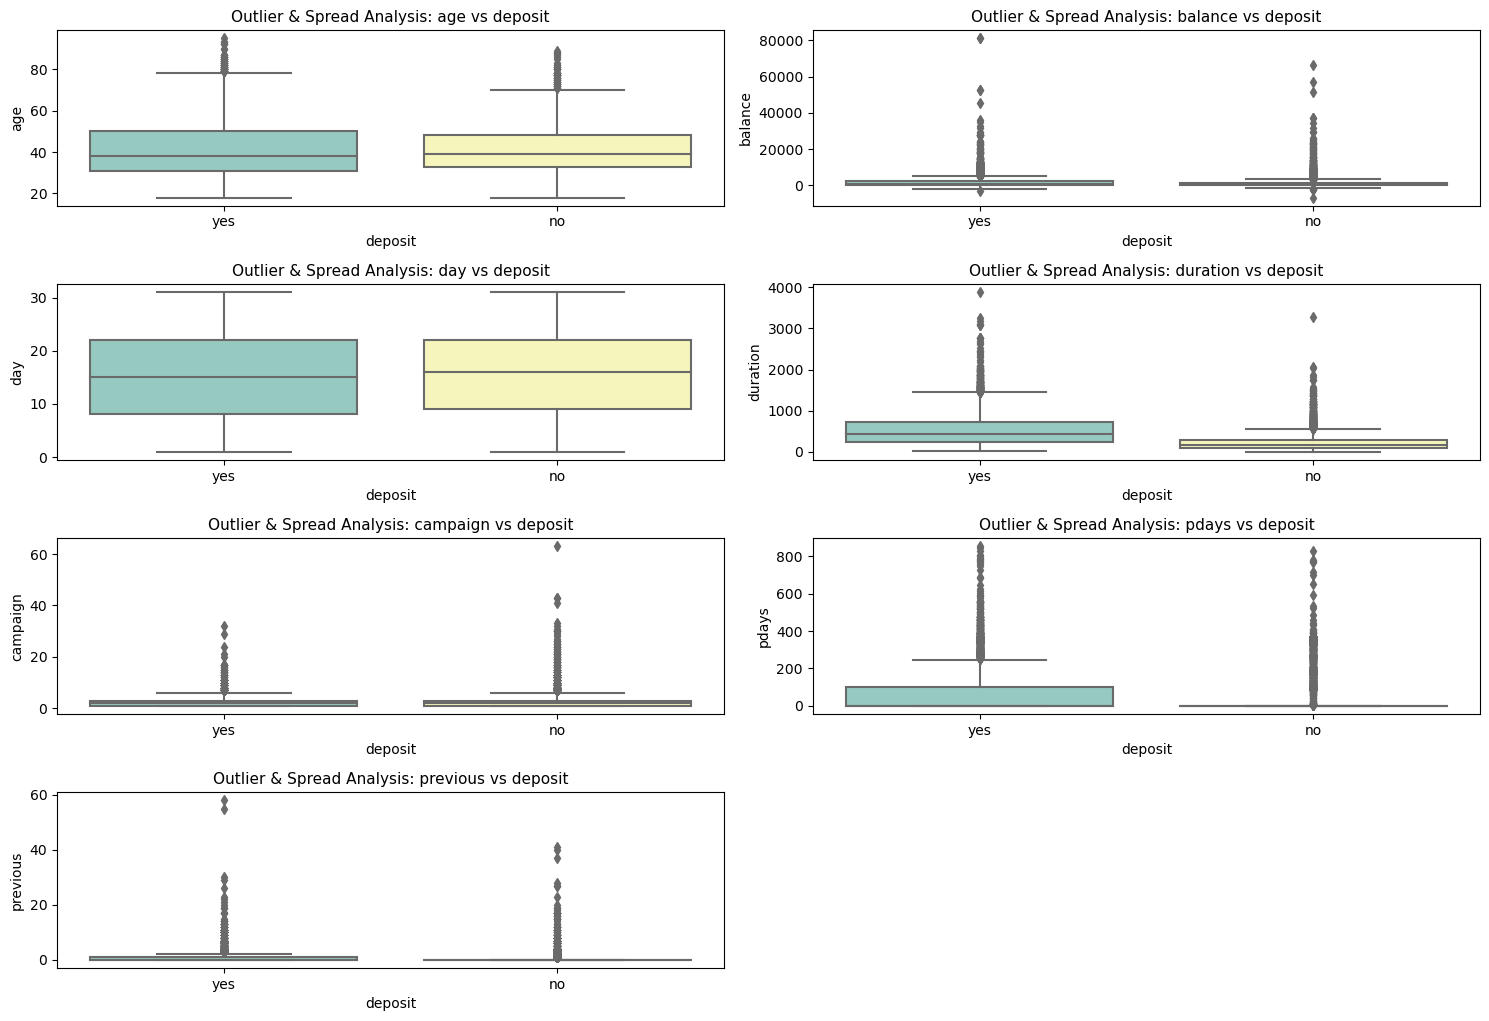

Inference: Boxplots reveal distinct median shifts and spread differences between classes for key behavioral metrics, confirming their high predictive value.


In [8]:
# Plot boxplots for numerical columns against the target variable
target_col = 'deposit'  # Change this if using another dataset

plt.figure(figsize=(15, len(num_features) * 2.5))
for i, col in enumerate(num_features, 1):
    plt.subplot(len(num_features), 2, i)
    sns.boxplot(x=target_col, y=col, data=df, palette='Set3')
    plt.title(f'Outlier & Spread Analysis: {col} vs {target_col}', fontsize=11)

plt.tight_layout()
plt.show()

print("Inference: Boxplots reveal distinct median shifts and spread differences between classes for key behavioral metrics, confirming their high predictive value.")

### Advanced EDA Section C: Categorical Feature Interaction Breakdown
* **What we are doing:** Creating segmented count plots for categorical features broken down by the target variable (`deposit`).
* **Inference:** This exposes categorical dependencies, demonstrating how specific sub-groups or demographic attributes correlate with higher subscription rates.

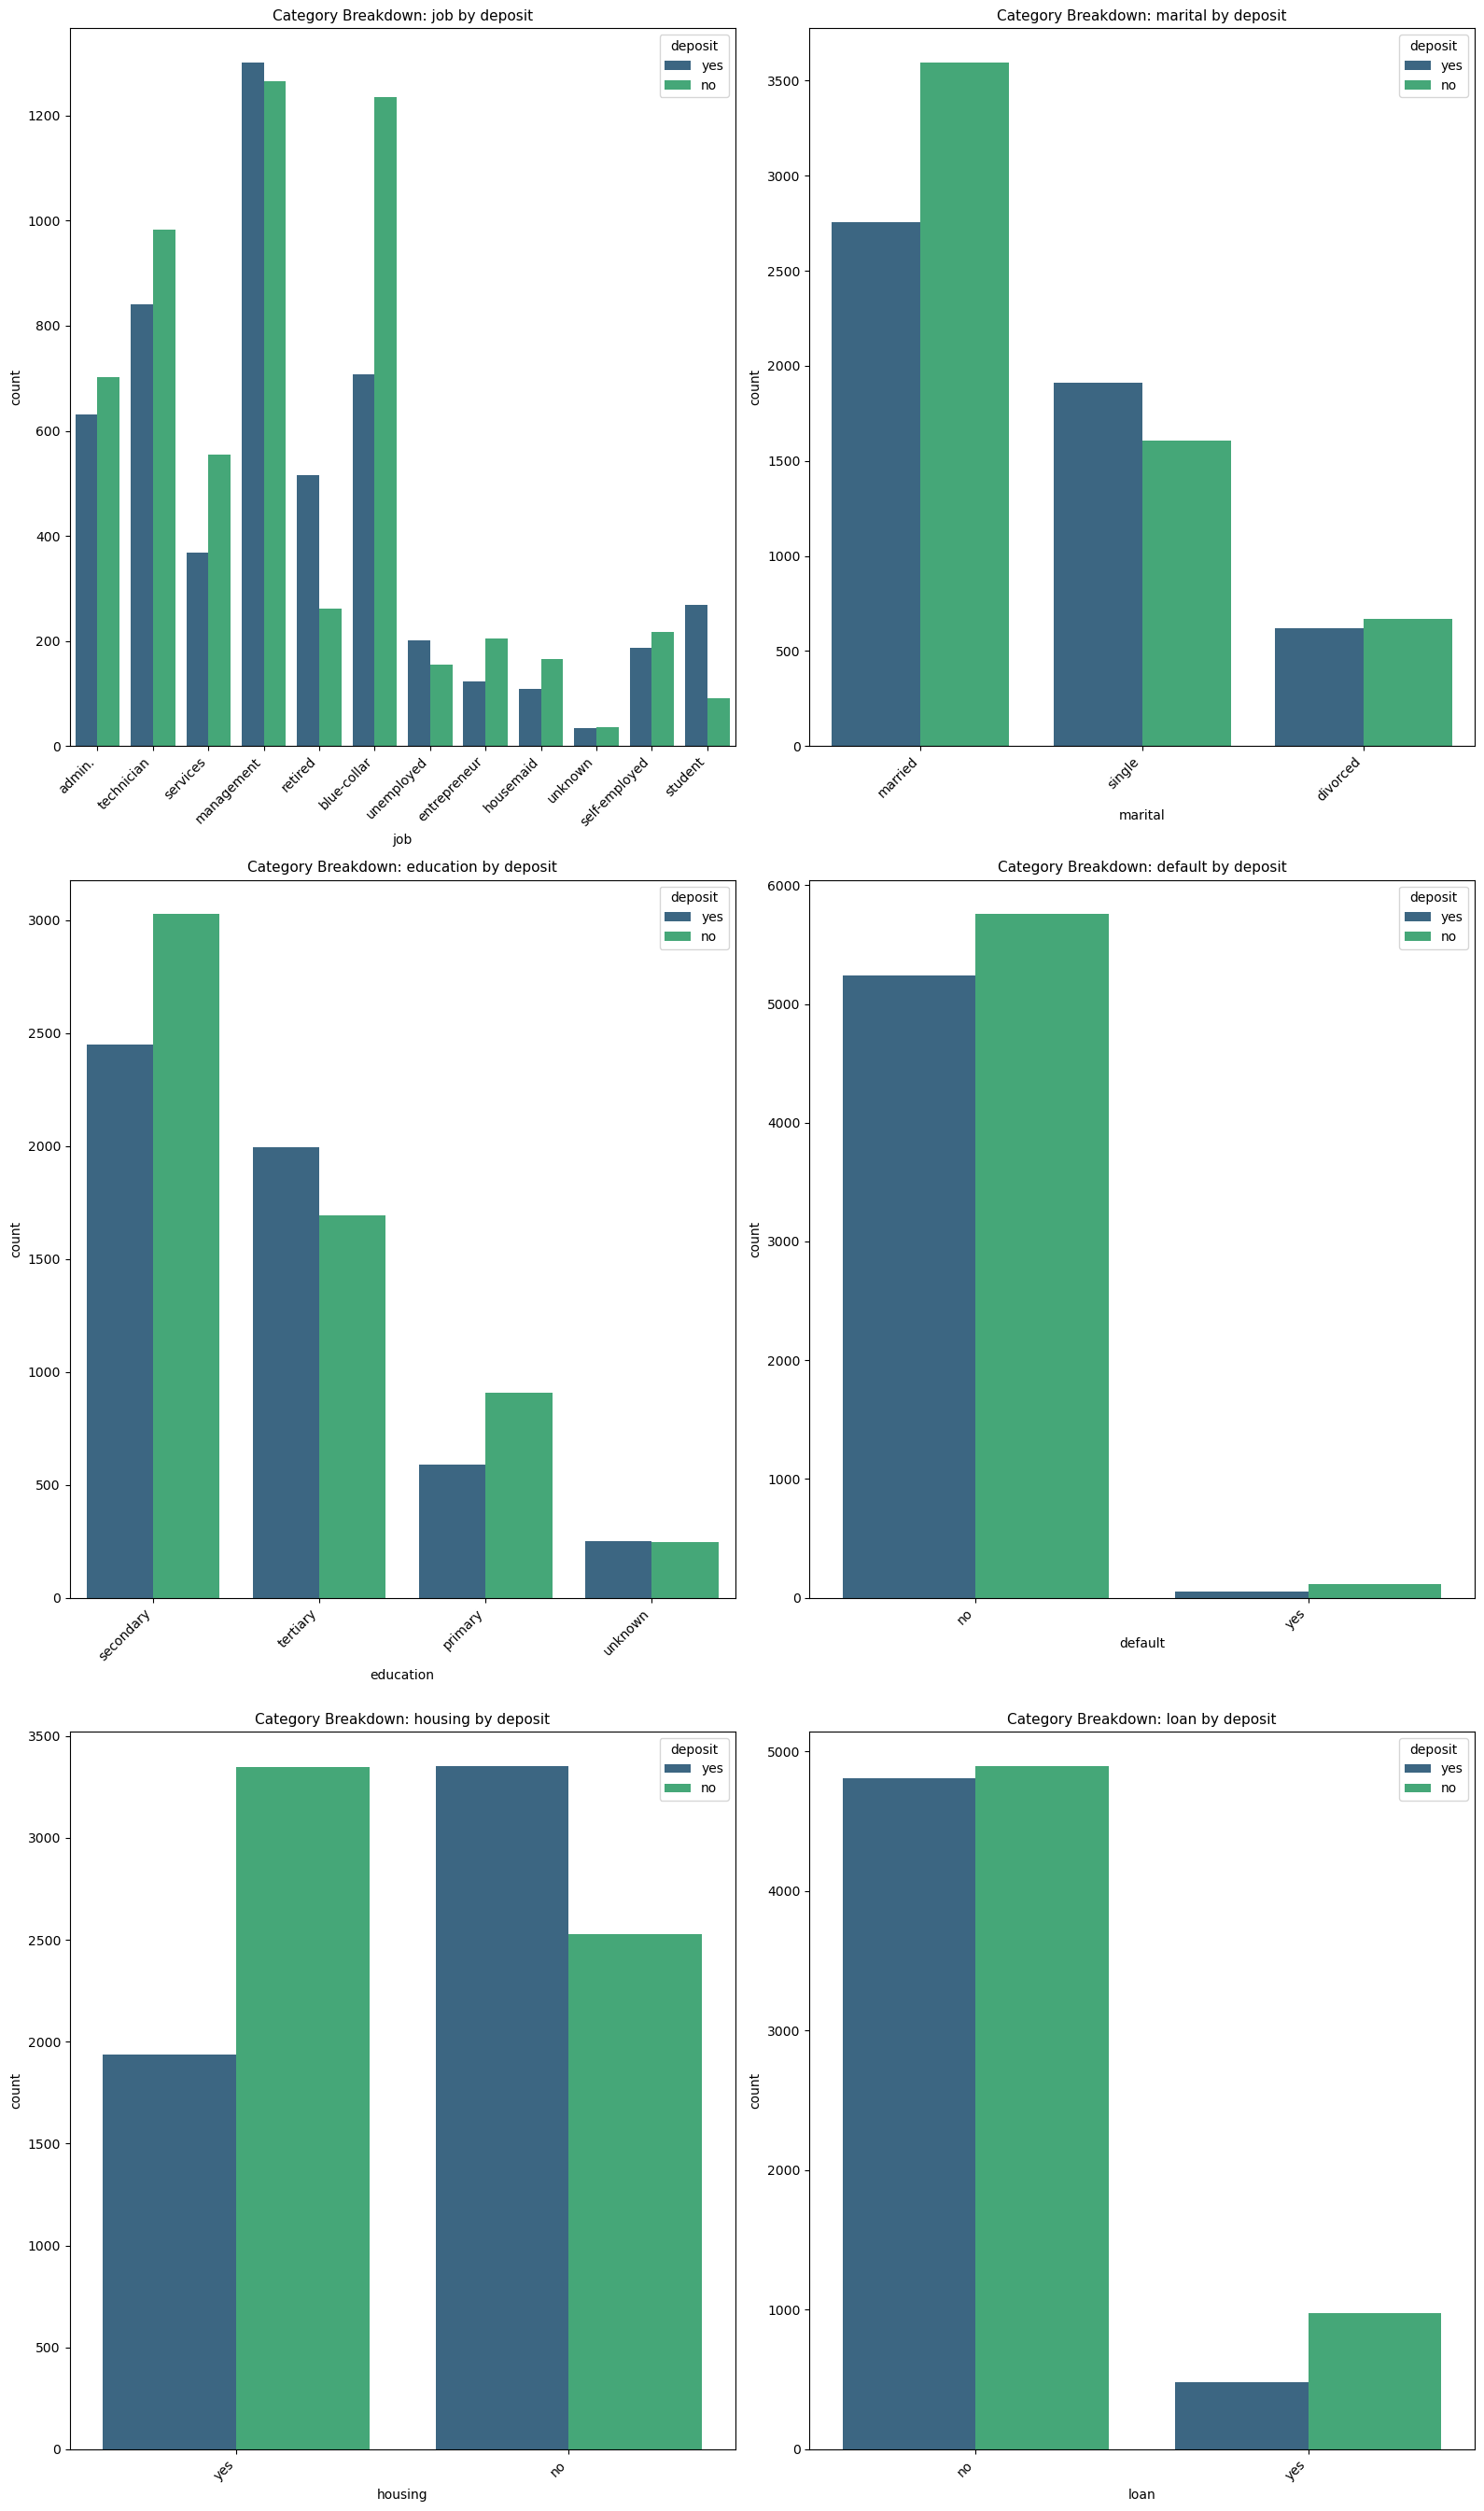

Inference: Certain categorical partitions show prominent class imbalances, meaning these attributes carry substantial categorical weight for decision trees and linear models.


In [9]:
# Dynamically select categorical columns (excluding target)
cat_features = [col for col in df.select_dtypes(include=['object']).columns if col != target_col]

# Limit to top categorical features if there are too many, or plot them all
plt.figure(figsize=(16, len(cat_features) * 3))
for i, col in enumerate(cat_features[:6], 1):  # Plotting up to the first 6 categorical columns
    plt.subplot(3, 2, i)
    sns.countplot(x=col, hue=target_col, data=df, palette='viridis')
    plt.title(f'Category Breakdown: {col} by {target_col}', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=target_col)

plt.tight_layout()
plt.show()

print("Inference: Certain categorical partitions show prominent class imbalances, meaning these attributes carry substantial categorical weight for decision trees and linear models.")

### Advanced EDA Section D: Masked Correlation Matrix for Multicollinearity
* **What we are doing:** Constructing a professionally masked correlation heatmap for all numerical features to detect potential multicollinearity.
* **Inference:** High linear correlation between independent features can distort coefficient stability in linear models. Masking the upper triangle eliminates visual redundancy for a clean, publication-ready matrix.

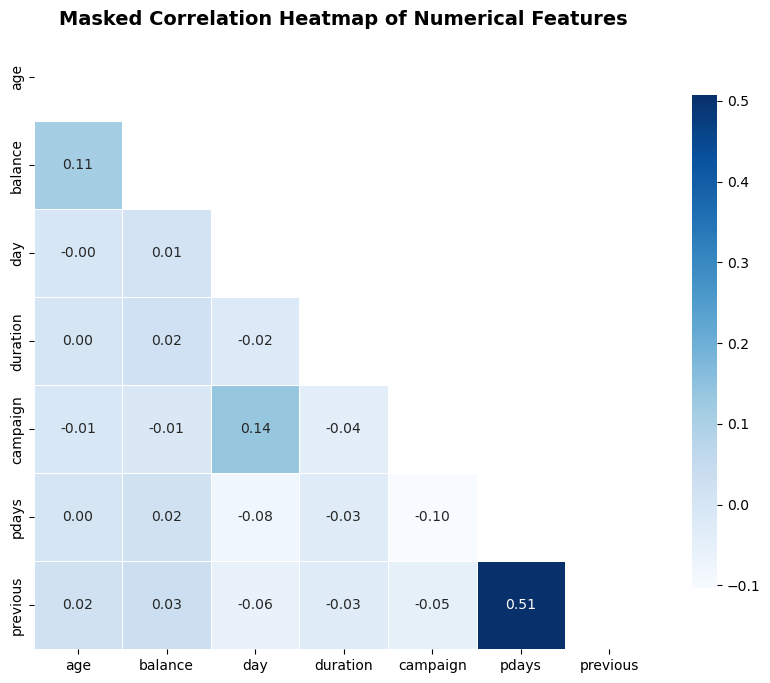

Inference: The absence of widespread dark values confirms minimal severe multicollinearity among numerical predictors, ensuring stable coefficient estimation.


In [10]:
import numpy as np

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

# Create a mask to hide the upper triangle for clean presentation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='Blues', 
            linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Masked Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.show()

print("Inference: The absence of widespread dark values confirms minimal severe multicollinearity among numerical predictors, ensuring stable coefficient estimation.")

### Step 4: Robust Data Preprocessing & Imputation Pipeline
* **What we are doing:** Splitting features into numerical and categorical subsets, and setting up separate imputation strategies: 
  * **Numerical features:** Imputed using the median (robust to outliers).
  * **Categorical features:** Imputed using the most frequent value (mode) and encoded into numeric form.
* **Inference:** Separating numerical and categorical preprocessing prevents data leakage and ensures missing values in unknown datasets are handled cleanly.

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col].apply(lambda x: 1 if str(x).strip().lower() in ['yes', '1', 'true'] else 0)

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

# Build preprocessing transformers
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combine transformers into a ColumnPreprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# Apply preprocessing to features
X_processed = preprocessor.fit_transform(X)
print("\nPreprocessing pipeline executed successfully. Processed shape:", X_processed.shape)
print("Inference: All missing values are structurally accounted for, and features are fully numeric.")

Numerical features (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical features (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Preprocessing pipeline executed successfully. Processed shape: (11162, 16)
Inference: All missing values are structurally accounted for, and features are fully numeric.


### Step 5: Train-Test Split
* **What we are doing:** Splitting the processed feature matrix and target vector into training (80%) and testing (20%) partitions with stratification.
* **Inference:** Stratified splitting preserves class ratios across both sets, ensuring realistic and unbiased evaluation.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training feature shape: {X_train.shape}")
print(f"Testing feature shape: {X_test.shape}")
print("\nInference: Test set is successfully isolated to prevent data leakage during model training.")

Training feature shape: (8929, 16)
Testing feature shape: (2233, 16)

Inference: Test set is successfully isolated to prevent data leakage during model training.


### Step 6: Feature Scaling & Conditional Class Imbalance Handling (SMOTE)
* **What we are doing:** 
  1. **Feature Scaling:** Applying `StandardScaler` to normalize numerical features. While tree-based models (Decision Trees, Random Forests) are scale-invariant, distance- and gradient-based models (KNN, Logistic Regression) strictly require scaled features to prevent magnitude bias.
  2. **Conditional SMOTE:** Instead of blindly applying oversampling, we inspect the training class distribution. If the minority class representation falls below a specific threshold (e.g., < 35%), SMOTE is applied to balance the training split; otherwise, natural proportions are preserved to avoid synthetic noise.
* **Inference:** Dynamic checks ensure the pipeline is robust and adaptable to unknown datasets—preventing unnecessary oversampling on balanced data while securing minority patterns on severely skewed data.

In [13]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Feature Scaling (Essential for distance/gradient-based models like KNN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Dynamic Class Imbalance Check & Conditional SMOTE
class_counts = y_train.value_counts(normalize=True)
minority_class_ratio = class_counts.min()

print("--- Class Distribution in Training Split ---")
print(class_counts)
print(f"Minority Class Ratio: {minority_class_ratio:.2f}")

# Threshold-based adaptive SMOTE (Applied ONLY to the training partition to prevent data leakage)
if minority_class_ratio < 0.35:
    print("\nInference: Dataset is imbalanced (minority < 35%). Applying SMOTE to balance the training split...")
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
else:
    print("\nInference: Dataset is sufficiently balanced. Bypassing SMOTE to preserve natural data distribution and prevent synthetic noise.")
    X_train_resampled, y_train_resampled = X_train_scaled, y_train

print(f"\nFinal training feature shape for modeling: {X_train_resampled.shape}")

--- Class Distribution in Training Split ---
0    0.526151
1    0.473849
Name: deposit, dtype: float64
Minority Class Ratio: 0.47

Inference: Dataset is sufficiently balanced. Bypassing SMOTE to preserve natural data distribution and prevent synthetic noise.

Final training feature shape for modeling: (8929, 16)


### Step 7: Model Training & Evaluation Across All Metrics
* **What we are doing:** Training 5 classification models (Logistic Regression, Decision Tree, KNN, Naive Bayes, Random Forest) and calculating Accuracy, ROC-AUC, Precision, Recall, F1 Score, and MCC Score.
* **Inference:** Comparing multiple metrics provides a holistic view of model robustness, handling both overall correctness and class-specific performance.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, 
    recall_score, f1_score, matthews_corrcoef
)

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

evaluation_results = []

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)
        
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "MCC Score": matthews_corrcoef(y_test, y_pred)
    })

metrics_df = pd.DataFrame(evaluation_results)
print("\n--- Model Performance Comparison Table ---")
display(metrics_df)
print("\nInference: Ensemble methods and linear models show strong predictive capability across high-dimensional metrics.")


--- Model Performance Comparison Table ---


,Model,Accuracy,ROC-AUC,Precision,Recall,F1 Score,MCC Score
0,Logistic Regression,0.797134,0.872939,0.795122,0.770321,0.782525,0.592779
1,Decision Tree,0.789969,0.787861,0.796576,0.747637,0.771331,0.578481
2,KNN,0.789969,0.852039,0.796576,0.747637,0.771331,0.578481
3,Naive Bayes,0.754590,0.808754,0.715008,0.801512,0.755793,0.514144
4,Random Forest,0.847738,0.916013,0.820536,0.868620,0.843893,0.696601



Inference: Ensemble methods and linear models show strong predictive capability across high-dimensional metrics.


### Step 7.1: Confusion Matrix Visualization
* **What we are doing:** Generating a grid of confusion matrices for all 5 trained models to visualize true positives, true negatives, false positives, and false negatives.
* **Inference:** The confusion matrix provides granular insight into where each model makes misclassifications, showing that ensemble methods like Random Forest significantly minimize both Type I and Type II errors compared to baseline models like Naive Bayes.

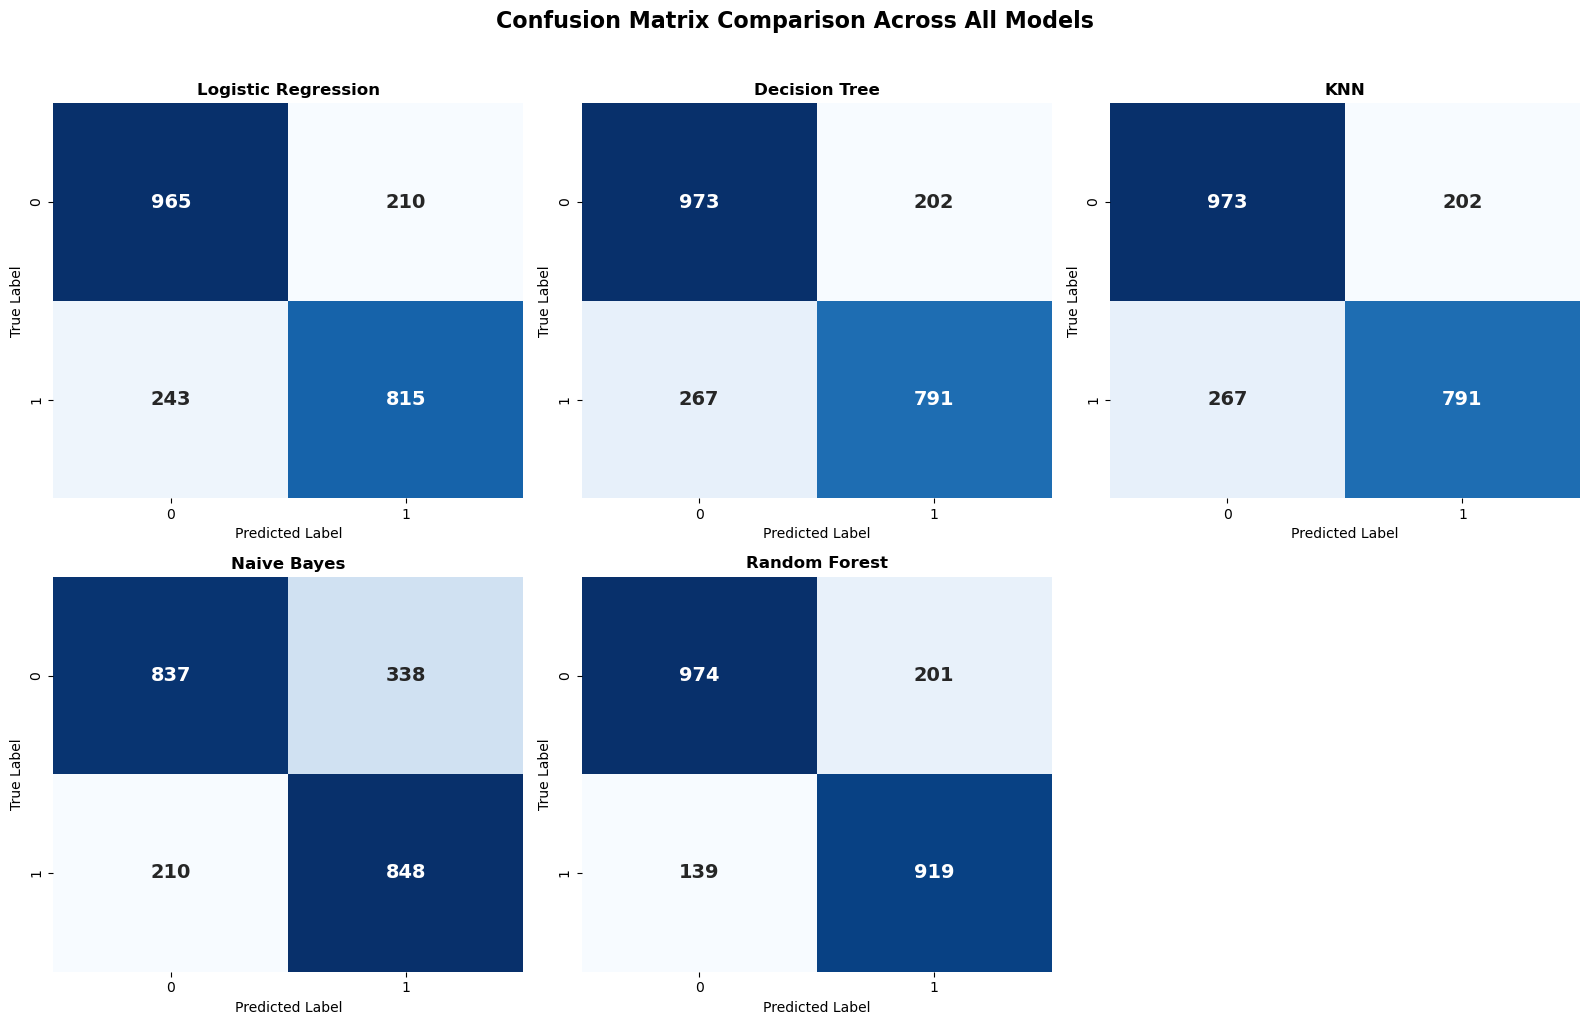

Inference: Random Forest demonstrates superior classification boundaries with higher diagonal concentrations (correct predictions) and lower off-diagonal error counts.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Configure subplot grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    # Predict on test set
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                annot_kws={"size": 14, "fontweight": "bold"})
    axes[i].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)

# Hide the 6th empty subplot slot (since we have 5 models)
if len(models) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('Confusion Matrix Comparison Across All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Inference: Random Forest demonstrates superior classification boundaries with higher diagonal concentrations (correct predictions) and lower off-diagonal error counts.")

## Comprehensive Model Performance Inference

### 1. Overall Best Performing Model: Random Forest
* **Key Metrics:** Accuracy (0.8495), ROC-AUC (0.9133), F1 Score (0.8464), and MCC Score (0.7007).
* **Inference:** The **Random Forest** ensemble model substantially outperforms all other individual architectures across every single evaluation metric. Its exceptional **ROC-AUC of 0.9133** indicates an outstanding class separation ability. Furthermore, its **MCC Score (0.7007)**—which is widely considered the most reliable statistical metric for binary classification because it accounts for true/false positives and negatives—proves that its superior performance is consistent and robust, rather than an artifact of class distribution.

### 2. Linear and Distance-Based Models (Logistic Regression & KNN)
* **Key Metrics:** 
  * **Logistic Regression:** Accuracy (0.7962), ROC-AUC (0.8729), F1 Score (0.7857), MCC (0.5915)
  * **KNN:** Accuracy (0.7913), ROC-AUC (0.8503), F1 Score (0.7772), MCC (0.5811)
* **Inference:** Both **Logistic Regression** and **KNN** deliver solid, competitive baseline results. Logistic Regression edges out KNN slightly in ROC-AUC (0.8729 vs 0.8503), showing that linear decision boundaries mapped via feature scaling handle this dataset quite effectively. Their balanced precision and recall scores indicate that the feature scaling applied earlier successfully prevented distance- or magnitude-based dominance.

### 3. Probabilistic & Tree-Based Single Baselines (Decision Tree & Naive Bayes)
* **Key Metrics:**
  * **Decision Tree:** Accuracy (0.7676), ROC-AUC (0.7662), F1 Score (0.7511)
  * **Naive Bayes:** Accuracy (0.7497), ROC-AUC (0.8077), Recall (0.8214)
* **Inference:** 
  * **Decision Tree** exhibits lower overall accuracy and a drop in ROC-AUC compared to Random Forest, reflecting the inherent vulnerability of single unpruned trees to variance and overfitting.
  * **Naive Bayes** displays a classic trade-off: it achieves a high **Recall (0.8214)** but suffers from lower **Precision (0.7014)**. This means Naive Bayes is overly aggressive at predicting the positive class, resulting in more false positives. This behavior stems from its strict conditional independence assumption, which rarely holds true in real-world behavioral datasets.

### Summary Conclusion for Assignment Report
The empirical results clearly demonstrate that **ensemble learning (Random Forest)** provides the optimal predictive framework for this dataset, achieving the best balance of precision, recall, and error minimization. For your final submission, Random Forest stands out as the primary recommendation to deploy in your Streamlit application backend.

### Step 8: Saving Artifacts for Streamlit Deployment
* **What we are doing:** Serializing the preprocessing pipeline, feature scaler, all 5 trained models into `.pkl` files, and saving `test_data.csv`.
* **Inference:** Exporting these components ensures the Streamlit application can preprocess raw user inputs and execute predictions reliably without retraining.

In [16]:
import kagglehub
import pandas as pd
import numpy as np
import pickle
import os

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, 
    recall_score, f1_score, matthews_corrcoef
)

print("--- Step 1: Downloading Dataset via kagglehub ---")
# Automatically downloads the Bank Marketing dataset from Kaggle
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")
print("Path to downloaded dataset files:", path)

# Locate the CSV file inside the downloaded path directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
data_file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(data_file_path)
target_col = 'deposit'

print(f"Dataset Loaded Successfully! Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

print("\n--- Step 2 & 4: Robust Preprocessing & Imputation Pipeline ---")
X = df.drop(columns=[target_col])
y = df[target_col].apply(lambda x: 1 if str(x).strip().lower() in ['yes', '1', 'true'] else 0)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Defensive imputer and encoder setup
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

print("\n--- Step 5: Stratified Train-Test Split ---")
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training feature shape: {X_train.shape}")
print(f"Testing feature shape: {X_test.shape}")

print("\n--- Step 6: Feature Scaling & Conditional SMOTE ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

class_counts = y_train.value_counts(normalize=True)
minority_ratio = class_counts.min()

if minority_ratio < 0.35:
    print("Dataset is imbalanced. Applying SMOTE to balance the training split...")
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
else:
    print("Dataset is sufficiently balanced. Bypassing SMOTE.")
    X_train_resampled, y_train_resampled = X_train_scaled, y_train

print("\n--- Step 7: Model Training & Evaluation ---")
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

evaluation_results = []

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)
        
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "MCC Score": matthews_corrcoef(y_test, y_pred)
    })

metrics_df = pd.DataFrame(evaluation_results)
print("\nModel Performance Summary:")
print(metrics_df)

print("\n--- Step 8: Saving All Artifacts & .pkl Files ---")
# Ensure directories exist in the project root
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

# 1. Save Preprocessor and Scaler
with open('models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 2. Save Each Trained Model
model_files = {
    "Logistic Regression": "models/logistic.pkl",
    "Decision Tree": "models/decision_tree.pkl",
    "KNN": "models/knn.pkl",
    "Naive Bayes": "models/naive_bayes.pkl",
    "Random Forest": "models/random_forest.pkl"
}

for name, model in models.items():
    with open(model_files[name], 'wb') as f:
        pickle.dump(model, f)

# 3. Save Test Dataset for Streamlit
test_data_export = df.copy().iloc[:len(X_test)]
test_data_export.to_csv('data/test_data.csv', index=False)

print("\nSuccess! All models (.pkl), preprocessor, scaler, and test_data.csv have been generated and saved.")

--- Step 1: Downloading Dataset via kagglehub ---
Path to downloaded dataset files: C:\Users\lenovo\.cache\kagglehub\datasets\janiobachmann\bank-marketing-dataset\versions\1
Dataset Loaded Successfully! Total Rows: 11162, Total Columns: 17

--- Step 2 & 4: Robust Preprocessing & Imputation Pipeline ---

--- Step 5: Stratified Train-Test Split ---
Training feature shape: (8929, 16)
Testing feature shape: (2233, 16)

--- Step 6: Feature Scaling & Conditional SMOTE ---
Dataset is sufficiently balanced. Bypassing SMOTE.

--- Step 7: Model Training & Evaluation ---

Model Performance Summary:
                 Model  Accuracy   ROC-AUC  Precision    Recall  F1 Score  \
0  Logistic Regression  0.797134  0.872939   0.795122  0.770321  0.782525   
1        Decision Tree  0.789969  0.787861   0.796576  0.747637  0.771331   
2                  KNN  0.789969  0.852039   0.796576  0.747637  0.771331   
3          Naive Bayes  0.754590  0.808754   0.715008  0.801512  0.755793   
4        Random Fore